# Load libraries 

In [22]:
import numpy as np  
import urllib.request
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd 
import calplot
import seaborn as sns
from scipy.stats import gaussian_kde

# Load data

In [9]:
sf_crime_data = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv")

In [11]:
sf_crime_data["Incident Date"] = pd.to_datetime(sf_crime_data ["Incident Date"], format="%Y-%m-%d")

# Convert 'Incident Time' to proper time format
sf_crime_data ["Incident Time"] = pd.to_datetime(sf_crime_data ["Incident Time"], format="%H:%M", errors="coerce").dt.time

## Part 1

From week 1's exercise, I'd like you to complete the "*Exercise 3*: Temporal patterns". The one where the main plot is the year-by-year evolution of the 10 focus crimes.

**IMPORTANT**: FOR THIS AND ALL SUBSEQUENT EXERCISES, I WANT YOU TO USE THE FULL DATASET FROM 2003 TO 2025.

The plot above already gives us a bit of information but does not tell us anything about how crimes changed over the years. Let's have a look at it!

> *Exercise 3*: Temporal patterns.
> * To start off easily, let's count the number of crimes per year:
>     * What is the year with most crimes? 
>     * What is the year with the fewest crimes?.
> * Create a barplot of crimes-per-year (years on the $x$-axis, crime-counts on the $y$-axis).
> * Finally, Police chief Suneman is interested in the temporal development of only a **subset of categories, the so-called *focus crimes***. Those categories are listed below (for convenient copy-paste action). Create bar-charts displaying the year-by-year development of each of these categories across the years 2003-2017.
> 

### 1.1 To start off easily, let's count the number of crimes per year:
- What is the year with most crimes? 
- What is the year with the fewest crimes?.

### 1.2 Create a barplot of crimes-per-year (years on the $x$-axis, crime-counts on the $y$-axis)

### 1.3 Create bar-charts displaying the year-by-year development of each of these categories across the years 2003-2017. **IN THIS CASE 2003-2025**

In [ ]:
focuscrimes = set(['WEAPON LAWS', 'PROSTITUTION', 'ROBBERY', 'BURGLARY', 'ASSAULT', 'DRUNKENNESS', 'DRUG/NARCOTIC', 'TRESPASS', 'LARCENY/THEFT', 'VANDALISM', 'VEHICLE THEFT', 'STOLEN PROPERTY'])

## Part 2

Next, I would like you to answer some of the questions related to the videos shown during week 2. Specifically, I would like you to

* Answer questions related to the main video-lecture on Data Visualization. (Where the first question is "What is the difference between *data* and *metadata*?")
* Answer questions related to the video on "Nice plots". That is, generate the list of 10 rules for nice plots.


> *Excercise:* Questions for the lecture. 
> 
> * What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?
> * Sune says that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye](http://cdn.ebaumsworld.com/mediaFiles/picture/718392/84732652.jpg). Explain why your example is difficult. 
> * Simpson's paradox is hard to explain. Come up with your own example - or find one on line.
> * In your own words, explain the differnece between *exploratory* and *explanatory* data analysis.
>



### 2.1 What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?

Metadata is the data that is telling us somthing about the data we are working with. Where the data it self is the observed information

### 2.2 Sune says that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye]

I agree that our eyes is really good for data analysis but at the same time we also need the descriptive statistics and numerical values as a dimension to undertand what is going on in a visiulizaiton. But in first glance our eyes gives a lot of great and fast information. I think our eyes becomes limited when working with darker environments, very dense areas and stuff that that is almost identical

### 2.3 Simpson's paradox is hard to explain. Come up with your own example - or find one online

## Part 3

We stay with week 2. I would also like you to complete the exercise in Week 2, Part 4, entitled "*Exercise*: Other cool ways to plot temporal data" (the one where we explore alternatives to bar-plots, such as calendar plots, for plotting temporal data).

In the exercise, i ask you to explore 3 different types of plots. For this assignment, you only need to do a calendar and polar bar chart.


### 3.1 Calender plot 

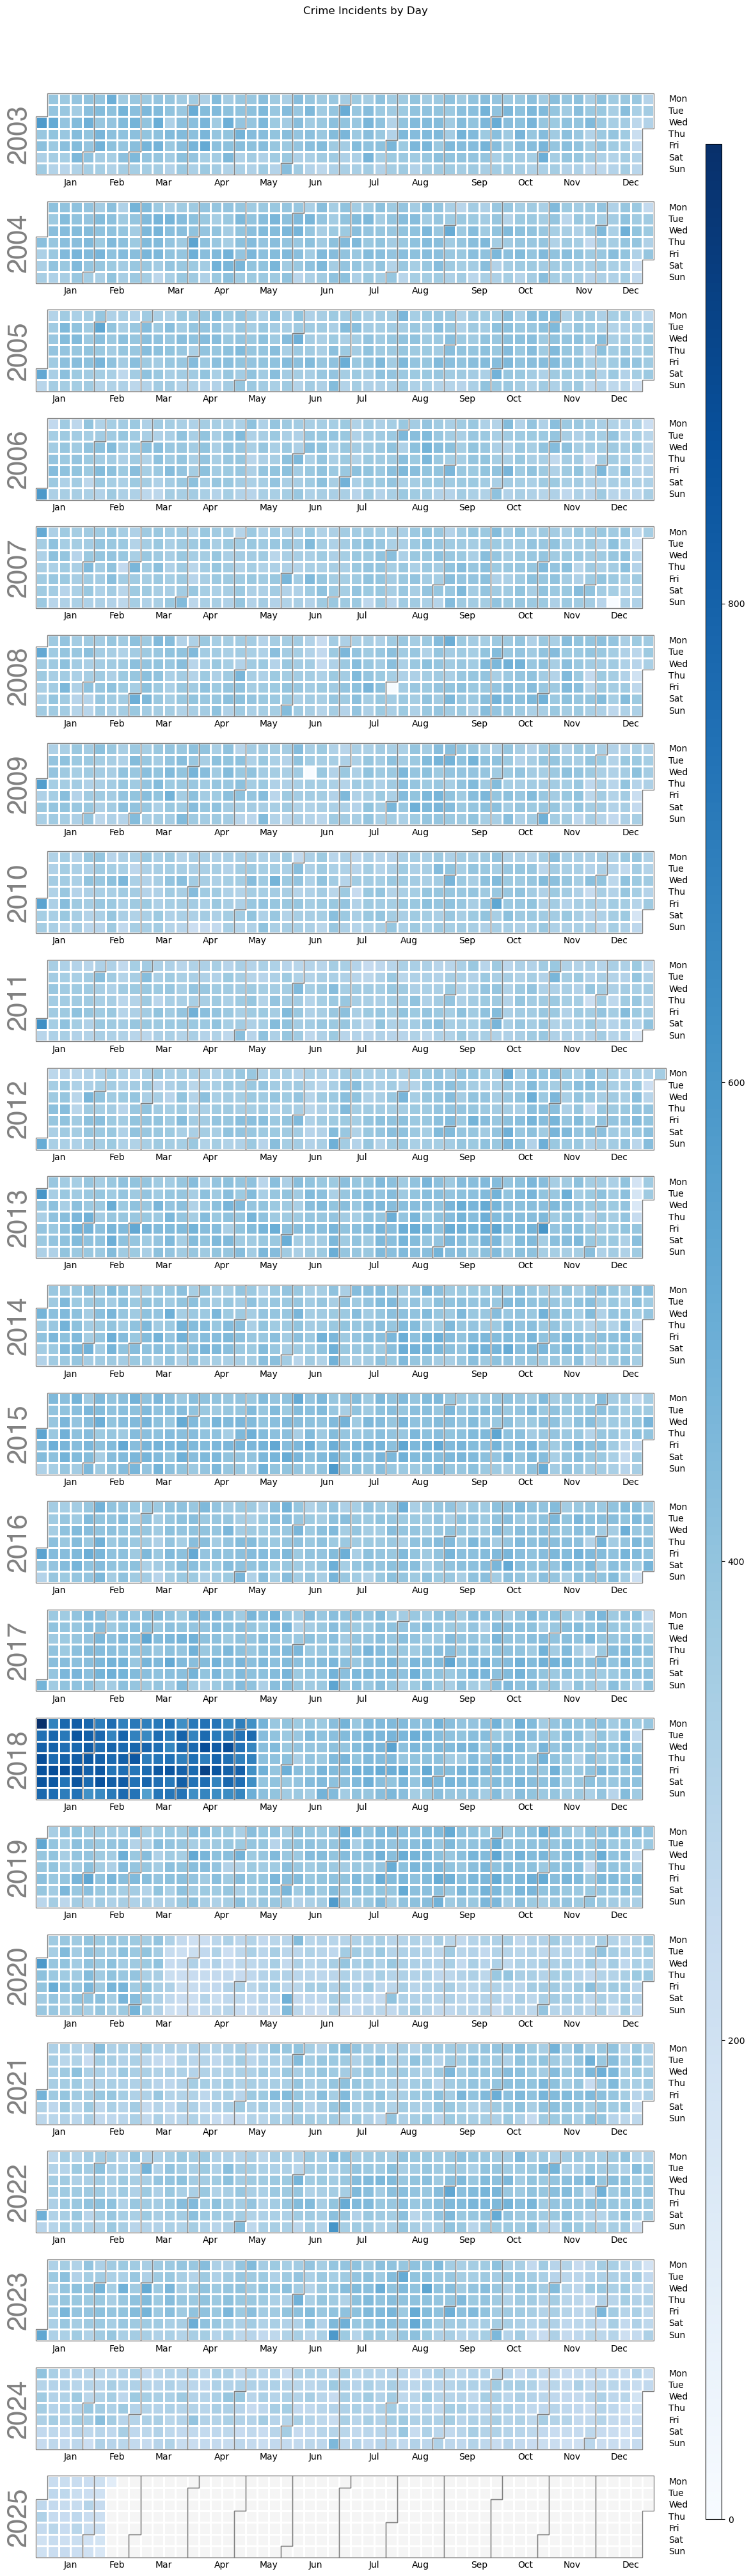

In [12]:
# Aggregate crime counts by date
crime_counts = sf_crime_data.groupby("Incident Date").size()

# Generate calendar heatmap
calplot.calplot(crime_counts, cmap="Blues", suptitle="Crime Incidents by Day", colorbar=True)

plt.show()

make comment on what it shows

### 3.2 Polar bar chart 

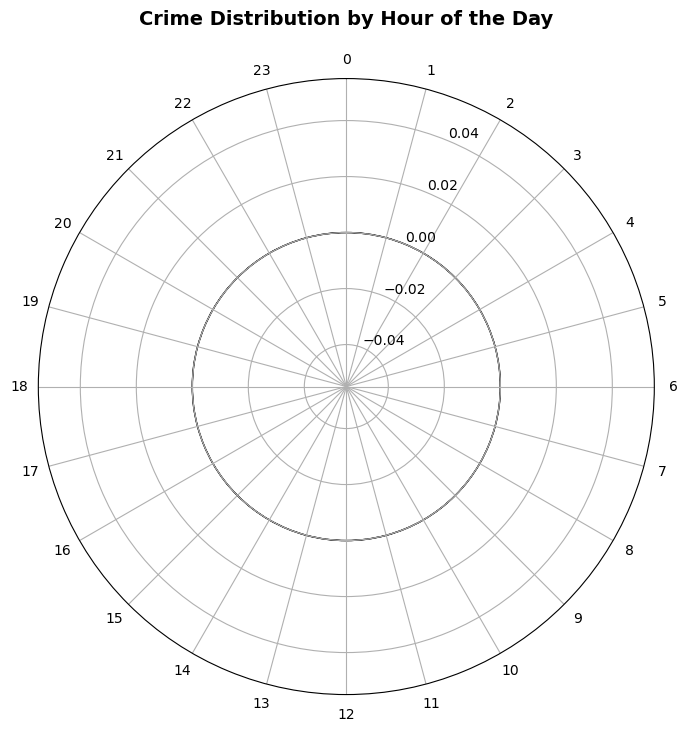

In [13]:
# Ensure 'Incident Time' is in datetime format, extracting only the hour
sf_crime_data["Incident Hour"] = pd.to_datetime(sf_crime_data["Incident Time"], format="%H:%M").dt.hour

# Count occurrences for each hour (0-23)
hourly_counts = sf_crime_data["Incident Hour"].value_counts().reindex(range(24), fill_value=0)

# Convert hour indices to radians for circular plotting
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)  # 24 hours mapped to full circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Create polar bar chart with better spacing and width
bars = ax.bar(theta, hourly_counts, width=np.pi/12, color="lightblue", edgecolor="black", alpha=0.75)

# Format plot
ax.set_xticks(theta)
ax.set_xticklabels(range(24))  # Hours from 0 to 23
ax.set_title("Crime Distribution by Hour of the Day", fontsize=14, fontweight="bold", pad=20)

# Ensure the 0-hour (midnight) is at the top
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

plt.show()

make comment on what it shows

## Part 4

From week 3, I'd like you to work on the exercise contained in Week 3, Part 3. Specifically, I would like you to **both** complete "*Excercise Part 1*: Connecting the dots and recreating plots from DAOST but using our own favorite dataset" and "*Excercise Part 2*". These exercises focus on reproducing figure 2.1, 2.4 and 2.11 and exploring a few more ideas from the book using data from SFPD.


In [ ]:
df_exercise1 = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv")
df_exercise2 = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/sf_crime_2003_present_cleaned.csv")

In [ ]:
df_exercise1["Incident Time"] = pd.to_datetime(df_exercise1["Incident Time"], format='%H:%M').dt.hour
df_exercise2["Incident Time"] = pd.to_datetime(df_exercise1["Incident Time"], format='%H:%M').dt.hour

### 4.1 Excercise part 1: Connecting the dots and recreating plots from DAOST but using our own favorite dataset.

#### 4.1.1 Let's make a jitter-plot (that is, code up something like **Figure 2-1** from DAOST from scratch)

/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_55238/3297908440.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Incident Time"] = pd.to_datetime(df_filtered["Incident Time"], format='%H:%M').dt.hour


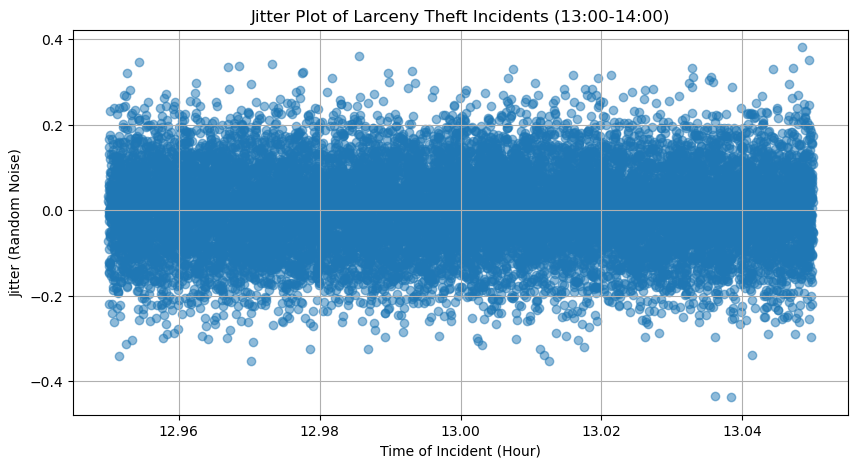

In [19]:
# Filter data for a specific crime type and time range
crime_type = "Larceny Theft"
df_filtered = df_exercise1[(df_exercise1["Incident Category"] == crime_type)]

# Focus on incidents between 13:00 and 14:00
df_filtered["Incident Time"] = pd.to_datetime(df_filtered["Incident Time"], format='%H:%M').dt.hour
df_hour = df_filtered[(df_filtered["Incident Time"] >= 13) & (df_filtered["Incident Time"] < 14)].copy()

# Add jitter for better visibility
df_hour["Jitter"] = np.random.normal(0, 0.1, size=len(df_hour))

# Create jitter plot
plt.figure(figsize=(10, 5))
plt.scatter(df_hour["Incident Time"] + np.random.uniform(-0.05, 0.05, len(df_hour)), df_hour["Jitter"], alpha=0.5)
plt.xlabel("Time of Incident (Hour)")
plt.ylabel("Jitter (Random Noise)")
plt.title(f"Jitter Plot of {crime_type} Incidents (13:00-14:00)")
plt.grid(True)
plt.show()

write comment to visualization 

#### 4.1.2 creating two crime-data based versions of the plot-type shown in DAOST **Figure 2-2**

Burglary count: 5852
Larceny Theft count: 21765


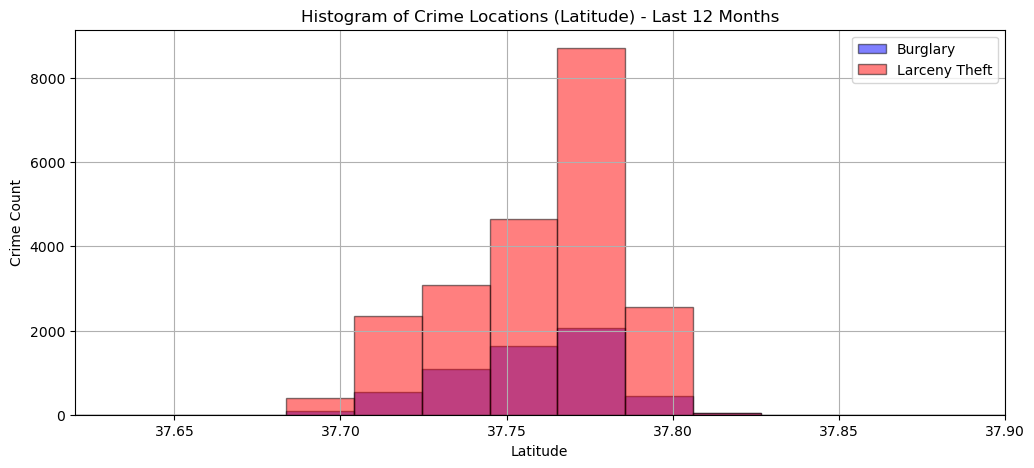

In [21]:
# Ensure the "Incident Date" column is in datetime format
df_exercise1["Incident Date"] = pd.to_datetime(df_exercise1["Incident Date"], errors='coerce')

# Choose two crime types with different geographic patterns
crime1 = "Burglary"
crime2 = "Larceny Theft"

# Select a suitable time range 
recent_date = df_exercise1["Incident Date"].max()  # Get the latest date in the dataset
time_filter = df_exercise1["Incident Date"] >= (recent_date - pd.DateOffset(months=12))

# Apply time filter and crime filter
df_crime1 = df_exercise1[(df_exercise1["Incident Category"] == crime1) & time_filter]
df_crime2 = df_exercise1[(df_exercise1["Incident Category"] == crime2) & time_filter]

# Drop missing or invalid latitudes (San Francisco latitudes should be ~37-38)
df_crime1 = df_crime1[(df_crime1["Latitude"] > 37) & (df_crime1["Latitude"] < 38)]
df_crime2 = df_crime2[(df_crime2["Latitude"] > 37) & (df_crime2["Latitude"] < 38)]

# Print data count to ensure between 1000-10000
print(f"Burglary count: {len(df_crime1)}")
print(f"Larceny Theft count: {len(df_crime2)}")

# Define bin edges for latitude (50 bins)
bins = np.linspace(37, 38, 50)

# Compute histogram counts using numpy.histogram
hist_crime1, _ = np.histogram(df_crime1["Latitude"], bins=bins)
hist_crime2, _ = np.histogram(df_crime2["Latitude"], bins=bins)

# Plot histograms manually
plt.figure(figsize=(12, 5))
plt.bar(bins[:-1], hist_crime1, width=np.diff(bins)[0], alpha=0.5, label=crime1, color='blue', edgecolor="black")
plt.bar(bins[:-1], hist_crime2, width=np.diff(bins)[0], alpha=0.5, label=crime2, color='red', edgecolor="black")
plt.xlabel("Latitude")
plt.ylabel("Crime Count")
plt.title("Histogram of Crime Locations (Latitude) - Last 12 Months")
plt.legend()
plt.grid(True)
plt.xlim(37.62, 37.9)  # Zoom in on the relevant latitude range
plt.show()

write comment to plot. Not sure if this plot is correct. Please check if i have done it correct. 

#### 4.1.3 Next up is using the plot-type shown in **Figure 2-4** from DAOST - Kernel density plot

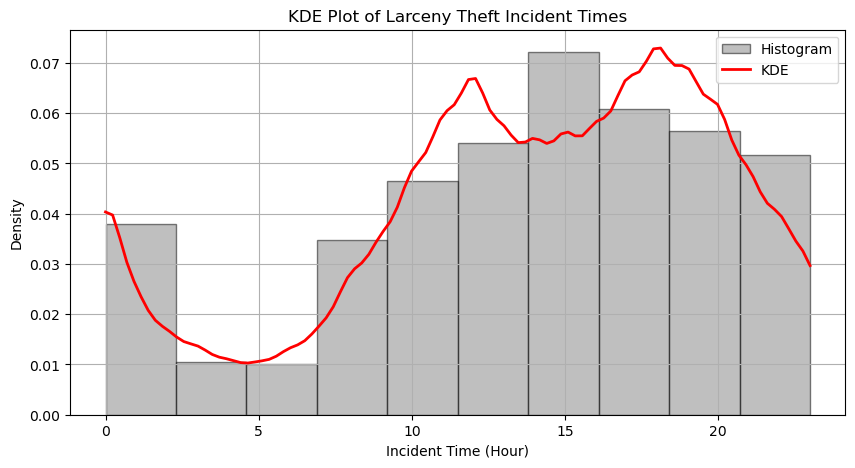

In [24]:
# Select a crime type and extract incident times
crime_type = "Larceny Theft"
df_filtered = df_exercise1[df_exercise1["Incident Category"] == crime_type]["Incident Time"].dropna()

# Ensure there's enough data
if len(df_filtered) < 10:
    print("Warning: Not enough data for KDE plot.")

# Compute KDE
kde = gaussian_kde(df_filtered)
x_vals = np.linspace(df_filtered.min(), df_filtered.max(), 100)
y_vals = kde(x_vals)

# Plot KDE and histogram
plt.figure(figsize=(10, 5))
plt.hist(df_filtered, bins=10, density=True, alpha=0.5, color="gray", label="Histogram", edgecolor="black")
plt.plot(x_vals, y_vals, color="red", label="KDE", linewidth=2)
plt.xlabel("Incident Time (Hour)")
plt.ylabel("Density")
plt.title(f"KDE Plot of {crime_type} Incident Times")
plt.legend()
plt.grid(True)

plt.show()

Remember we should comment on graphs

### 4.2 Excercise part 2: These exercises focus on reproducing figure 2.1, 2.4 and 2.11 and exploring a few more ideas from the book using data from SFPD.

#### 4.2.1  Now we'll work on creating two versions of the plot in **Figure 2-11**, but using the GPS data you used for your version of Figure 2-2. Comment on the result. It is not easy to create this plot from scracth.  

#### 4.2.2 We need some box plots. Here, I'd like you to use the box plots to visualize fluctuations of how many crimes happen per day. We'll use data from the 15 focus crimes defined last week

#### 4.2.2.1 For the full time-span of the data, calulate the **number of crimes per day** within each category for the entire duration of the data.

#### 4.2.2.2 Create a box-and whiskers plot showing the mean, median, quantiles, etc for all 15 crime-types side-by-side
- What does this plot reveal that you can't see in the plots from last time?

### 4.2.3 Another interesting use of box plots

## Part 5

Finally, I'd like you to work on the exercise "*Exercise*: Using all the tools to understand the temporal trends of prostitution in SF over time" in Week 4, Part 3. 

# Part 3: Putting everything you've learned to work

Now you've learned about lots of time-series analysis tricks and visualization. That means it's time for you to think for yourself with a slightly more independent exercise.

> *Exercise*: Using all the tools to understand the temporal trends of prostitution in SF over time.
> * It's quite simple really, I'd like you to present your own analysis of what happens to the `PROSTITUTION`
> crime type in SF over time.
>   - Hint 1: So think about trends over time, does every district show the same behavior?, or the same beahavior over time?, are there hotspots?, etc. A fancy way of saying this is: think about quantifying and explaining spatio-temporal patterns.
>   - Hint 2: It's a good idea to think of this exercise as a way to show off what you've learned about data analysis in this and the previous lectures: so it's a good idea to include many of the types of plots from the curriculum so far in your analysis.
> * As an extra little thing, I also want you to reflect on the *role of data errors* in an analysis. Data errors could be things like imprecise GPS points, or imprecise recording of time.


# Contribution

In [1]:
contribution_dict = {
  "Student:s200513": "Write here",
  "Student:x": "Write here",
  "student:x": "Write here",
}

In [3]:
for student, contribution in contribution_dict.items():
  print(f"{student}: {contribution}")

Student:s200513: Write here
Student:x: Write here
student:x: Write here
